In [1]:
# -- Robustness Check 1: Jan 21 RV Fix --
# Current: RV from BXM_History (understates true SPX RV)
# Fix: Use SPX data from 2021 to compute true 21-day RV for Jan 21

import pandas as pd
import numpy as np

# Load BXM_History for 2021 tail
bxm_hist = pd.read_csv("../data/raw/BXM_History.csv")
bxm_hist['DATE'] = pd.to_datetime(bxm_hist['DATE'])

# We need SPX, not BXM -- check if we have SPX_Bloomberg with 2021 data
# BXM_History only has BXM, so let's check other files
import os
files = os.listdir("../data/raw/")
print("Available files in data/raw:")
for f in sorted(files):
    print(f" {f}")

Available files in data/raw:
 BXMD_Bloomberg_2022.csv
 BXM_Bloomberg_2022.csv
 BXM_History.csv
 Equity EOD Summary
 HistoricalData_PBP.csv
 PBP_Bloomberg_2022.csv
 SPX_Bloomberg_2022.csv
 VIX_Bloomberg_2022.csv
 cboe_spx_2022


In [2]:
# -- Check available files for 2021 SPX data --

# Check HistoricalData_PBP.csv
pbp_hist = pd.read_csv("../data/raw/HistoricalData_PBP.csv")
print("=== HistoricalData_PBP.csv ===")
print(pbp_hist.head(3))
print(f"Columns: {pbp_hist.columns.tolist()}")
print()

# Check VIX_Bloomberg_2022.csv
vix_raw = pd.read_csv("../data/raw/VIX_Bloomberg_2022.csv", header=None, skiprows=6)
vix_raw.columns = ['date', 'vix_close', 'vix_open', 'vix_high', 'vix_low']
vix_raw['date'] = pd.to_datetime(vix_raw['date'], errors='coerce')
vix_raw = vix_raw.dropna(subset=['date'])
print("=== VIX_Bloomberg_2022.csv ===")
print(f"Date range: {vix_raw['date'].min()} ~ {vix_raw['date'].max()}")
print()

# Extract SPX from tick data Jan 3 - Jan 21
import glob, os

tick_path = "../data/raw/cboe_spx_2022/"
spx_jan = []
for f in sorted(glob.glob(tick_path + "UnderlyingOptionsTradesCalcs_2022-01-*.csv")):
    date_str = os.path.basename(f).replace("UnderlyingOptionsTradesCalcs_","").replace(".csv","")
    df = pd.read_csv(f, usecols=['quote_datetime','underlying_bid','underlying_ask'])
    df['quote_datetime'] = pd.to_datetime(df['quote_datetime'])
    last = df.iloc[-1]
    mid = (last['underlying_bid'] + last['underlying_ask']) / 2
    spx_jan.append({'date': pd.to_datetime(date_str), 'spx': mid})

df_spx_jan = pd.DataFrame(spx_jan)
print("=== SPX from tick data (Jan 2022) ===")
print(f"Days available: {len(df_spx_jan)}")
print(df_spx_jan)

=== HistoricalData_PBP.csv ===
         Date  Close/Last  Volume   Open   High      Low
0  05/26/2026       22.77   39375  22.78  22.79  22.7177
1  05/22/2026       22.71   27247  22.75  22.78  22.6750
2  05/21/2026       22.66   37020  22.60  22.67  22.5100
Columns: ['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']



ValueError: Length mismatch: Expected axis has 2 elements, new values have 5 elements

In [3]:
# -- Check available files for 2021 SPX data --

# Check HistoricalData_PBP.csv
pbp_hist = pd.read_csv("../data/raw/HistoricalData_PBP.csv")
print("=== HistoricalData_PBP.csv ===")
print(pbp_hist.head(3))
print(f"Columns: {pbp_hist.columns.tolist()}")
print()

# Check VIX structure first
vix_raw = pd.read_csv("../data/raw/VIX_Bloomberg_2022.csv", header=None, skiprows=6)
print("=== VIX_Bloomberg_2022.csv structure ===")
print(f"Columns: {vix_raw.shape[1]}")
print(vix_raw.head(3))
print()

# Extract SPX from tick data Jan 2022
import glob, os
tick_path = "../data/raw/cboe_spx_2022/"
spx_jan = []
for f in sorted(glob.glob(tick_path + "UnderlyingOptionsTradesCalcs_2022-01-*.csv")):
    date_str = os.path.basename(f).replace("UnderlyingOptionsTradesCalcs_","").replace(".csv","")
    df = pd.read_csv(f, usecols=['quote_datetime','underlying_bid','underlying_ask'])
    df['quote_datetime'] = pd.to_datetime(df['quote_datetime'])
    last = df.iloc[-1]
    mid = (last['underlying_bid'] + last['underlying_ask']) / 2
    spx_jan.append({'date': pd.to_datetime(date_str), 'spx': mid})

df_spx_jan = pd.DataFrame(spx_jan)
print("=== SPX from tick data (Jan 2022) ===")
print(f"Days: {len(df_spx_jan)}")
print(df_spx_jan)

=== HistoricalData_PBP.csv ===
         Date  Close/Last  Volume   Open   High      Low
0  05/26/2026       22.77   39375  22.78  22.79  22.7177
1  05/22/2026       22.71   27247  22.75  22.78  22.6750
2  05/21/2026       22.66   37020  22.60  22.67  22.5100
Columns: ['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

=== VIX_Bloomberg_2022.csv structure ===
Columns: 2
          0      1
0  1/3/2022  16.60
1  1/4/2022  16.91
2  1/5/2022  19.73

=== SPX from tick data (Jan 2022) ===
Days: 20
         date        spx
0  2022-01-03  4787.3485
1  2022-01-04  4791.1279
2  2022-01-05  4700.0291
3  2022-01-06  4699.6020
4  2022-01-07  4685.6560
5  2022-01-10  4602.5069
6  2022-01-11  4708.4047
7  2022-01-12  4727.4478
8  2022-01-13  4695.9783
9  2022-01-14  4623.5925
10 2022-01-18  4595.5328
11 2022-01-19  4592.6960
12 2022-01-20  4476.3630
13 2022-01-21  4475.0804
14 2022-01-24  4225.5528
15 2022-01-25  4384.4905
16 2022-01-26  4346.0585
17 2022-01-27  4413.5303
18 2022-01-28  4371.5085

In [5]:
# -- Fix Jan 21 RV: Get Dec 2021 SPX from Yahoo Finance --
# Need ~8 trading days from Dec 2021 to complete 21-day window before Jan 21

# pip install yfinance if needed
import yfinance as yf

# Download SPX Dec 2021 ~ Jan 2022
spx_yahoo = yf.download("^GSPC",
                         start="2021-12-01",
                         end="2022-01-22",
                         progress=False)

spx_yahoo = spx_yahoo[['Close']].reset_index()
spx_yahoo.columns = ['date', 'spx']
spx_yahoo['date'] = pd.to_datetime(spx_yahoo['date'])
spx_yahoo = spx_yahoo.sort_values('date').reset_index(drop=True)

print(f"Downloaded: {len(spx_yahoo)} days")
print(f"Date range: {spx_yahoo['date'].min()} ~ {spx_yahoo['date'].max()}")
print(spx_yahoo.tail(10))

Downloaded: 36 days
Date range: 2021-12-01 00:00:00 ~ 2022-01-21 00:00:00
         date          spx
26 2022-01-07  4677.029785
27 2022-01-10  4670.290039
28 2022-01-11  4713.069824
29 2022-01-12  4726.350098
30 2022-01-13  4659.029785
31 2022-01-14  4662.850098
32 2022-01-18  4577.109863
33 2022-01-19  4532.759766
34 2022-01-20  4482.729980
35 2022-01-21  4397.939941


In [6]:
# -- Compute True 21-day RV for Jan 21 --

spx_yahoo['log_ret'] = np.log(spx_yahoo['spx'] / spx_yahoo['spx'].shift(1))
spx_yahoo['rv_21'] = spx_yahoo['log_ret'].rolling(21).std() * np.sqrt(252)

# Jan 21 RV
jan21_rv_true = spx_yahoo[spx_yahoo['date'] == pd.to_datetime('2022-01-21')]['rv_21'].values[0]
print(f"Jan 21 RV (BXM proxy, old): 0.0917 (9.17%)")
print(f"Jan 21 RV (SPX Yahoo, new): {jan21_rv_true:.4f} ({jan21_rv_true*100:.2f}%)")
print()

# Update IV-RV spread for Jan 21
jan21_iv = 0.2299
old_spread = jan21_iv - 0.0917
new_spread = jan21_iv - jan21_rv_true
old_signal = "BXM" if old_spread > 0 else "BXMD"
new_signal = "BXM" if new_spread > 0 else "BXMD"

print(f"IV (Jan 21):         {jan21_iv:.4f}")
print(f"Old spread:          {old_spread:.4f} → Signal: {old_signal}")
print(f"New spread:          {new_spread:.4f} → Signal: {new_signal}")
print()
if old_signal != new_signal:
    print("⚠️  Signal changed! Stage 3 results need updating.")
else:
    print("✅ Signal unchanged. Stage 3 results unaffected.")

Jan 21 RV (BXM proxy, old): 0.0917 (9.17%)
Jan 21 RV (SPX Yahoo, new): 0.1535 (15.35%)

IV (Jan 21):         0.2299
Old spread:          0.1382 → Signal: BXM
New spread:          0.0764 → Signal: BXM

✅ Signal unchanged. Stage 3 results unaffected.


In [7]:
# -- Robustness Check 2: BXMD Validation --
# Compare our Static BXMD returns vs official BXMD_Bloomberg_2022.csv

bxmd_raw = pd.read_csv("../data/raw/BXMD_Bloomberg_2022.csv", header=None, skiprows=6)
print("=== BXMD_Bloomberg_2022.csv structure ===")
print(f"Columns: {bxmd_raw.shape[1]}")
print(bxmd_raw.head(3))

=== BXMD_Bloomberg_2022.csv structure ===
Columns: 2
          0        1
0  1/3/2022  3788.29
1  1/4/2022  3788.29
2  1/5/2022  3745.12


In [8]:
# -- Parse BXMD Bloomberg and compare with Static BXMD --

bxmd_raw.columns = ['date', 'bxmd_close']
bxmd_raw['date'] = pd.to_datetime(bxmd_raw['date'])
bxmd_raw['bxmd_close'] = pd.to_numeric(bxmd_raw['bxmd_close'], errors='coerce')
bxmd_bloomberg = bxmd_raw.sort_values('date').reset_index(drop=True)

# Roll dates
roll_dates = pd.to_datetime([
    "2022-01-21", "2022-02-18", "2022-03-18", "2022-04-14",
    "2022-05-20", "2022-06-17", "2022-07-15", "2022-08-19",
    "2022-09-16", "2022-10-21", "2022-11-18", "2022-12-16"
])

# Extract BXMD on roll dates
bxmd_roll = bxmd_bloomberg[bxmd_bloomberg['date'].isin(roll_dates)][
    ['date', 'bxmd_close']
].sort_values('date').reset_index(drop=True)

# Compute official BXMD expiry-to-expiry returns
bxmd_roll['r_bxmd_official'] = np.log(
    bxmd_roll['bxmd_close'] / bxmd_roll['bxmd_close'].shift(1)
)
bxmd_roll = bxmd_roll.dropna().reset_index(drop=True)

# Our Static BXMD returns (from jul13)
r_bxmd_ours = [-0.00096, 0.03320, -0.00460, -0.10912,
               -0.04061, 0.05646, 0.04015, -0.07718,
               -0.01639, 0.04843, -0.01714]

bxmd_roll['r_bxmd_ours'] = r_bxmd_ours
bxmd_roll['diff'] = bxmd_roll['r_bxmd_official'] - bxmd_roll['r_bxmd_ours']

print("=== BXMD Validation: Official vs Ours ===")
print(f"{'Period End':<12} {'Official':>10} {'Ours':>10} {'Diff':>10}")
print("-" * 46)
for _, row in bxmd_roll.iterrows():
    print(f"{str(row['date'].date()):<12} "
          f"{row['r_bxmd_official']*100:>9.3f}% "
          f"{row['r_bxmd_ours']*100:>9.3f}% "
          f"{row['diff']*100:>9.3f}%")

print(f"\nMean diff : {bxmd_roll['diff'].mean()*100:.4f}%")
print(f"Std diff  : {bxmd_roll['diff'].std()*100:.4f}%")
print(f"Max |diff|: {bxmd_roll['diff'].abs().max()*100:.4f}%")

=== BXMD Validation: Official vs Ours ===
Period End     Official       Ours       Diff
----------------------------------------------
2022-02-18      -0.277%    -0.096%    -0.181%
2022-03-18       3.296%     3.320%    -0.024%
2022-04-14      -0.101%    -0.460%     0.359%
2022-05-20     -11.240%   -10.912%    -0.328%
2022-06-17      -4.550%    -4.061%    -0.489%
2022-07-15       5.542%     5.646%    -0.104%
2022-08-19       3.835%     4.015%    -0.180%
2022-09-16      -7.905%    -7.718%    -0.187%
2022-10-21      -2.198%    -1.639%    -0.559%
2022-11-18       3.951%     4.843%    -0.892%
2022-12-16      -1.688%    -1.714%     0.026%

Mean diff : -0.2325%
Std diff  : 0.3318%
Max |diff|: 0.8924%


In [9]:
# -- Robustness Check 3: Sensitivity Analysis on IV-RV Threshold --

# IV-RV spreads at each roll date (Jan 21 updated)
spreads = {
    pd.to_datetime("2022-01-21"): 0.0764,   # updated with true SPX RV
    pd.to_datetime("2022-02-18"): 0.0184,
    pd.to_datetime("2022-03-18"): -0.0570,
    pd.to_datetime("2022-04-14"): 0.0168,
    pd.to_datetime("2022-05-20"): -0.0721,
    pd.to_datetime("2022-06-17"): -0.0097,
    pd.to_datetime("2022-07-15"): -0.0095,
    pd.to_datetime("2022-08-19"): 0.0053,
    pd.to_datetime("2022-09-16"): 0.0027,
    pd.to_datetime("2022-10-21"): -0.0053,
    pd.to_datetime("2022-11-18"): -0.0586,
    pd.to_datetime("2022-12-16"): 0.0073,
}

# Returns per period
r_bxm_periods  = [0.00693, 0.03832, 0.00254, -0.09799,
                  -0.02312, 0.03263, 0.01941, -0.06613,
                  0.00206, 0.01601, -0.00078]

r_bxmd_periods = [-0.00096, 0.03320, -0.00460, -0.10912,
                  -0.04061, 0.05646, 0.04015, -0.07718,
                  -0.01639, 0.04843, -0.01714]

roll_dates_list = sorted(spreads.keys())

thresholds = [-0.05, -0.02, 0.00, 0.02, 0.05]

print("=== Sensitivity Analysis: IV-RV Threshold ===\n")
print(f"{'Threshold':>10} {'BXM%':>6} {'BXMD%':>6} {'Ann.Ret':>10} {'R/R':>8} {'Signal Split':>14}")
print("-" * 60)

for thresh in thresholds:
    r_dynamic = []
    bxm_count = 0
    bxmd_count = 0

    for i, d in enumerate(roll_dates_list[1:]):
        prev_date = roll_dates_list[i]
        spread = spreads[prev_date]
        if spread > thresh:
            r_dynamic.append(r_bxm_periods[i])
            bxm_count += 1
        else:
            r_dynamic.append(r_bxmd_periods[i])
            bxmd_count += 1

    ann_ret = np.mean(r_dynamic) * 12
    ann_std = np.std(r_dynamic, ddof=1) * np.sqrt(12)
    rtr = ann_ret / ann_std

    print(f"{thresh:>10.2f} {bxm_count:>6} {bxmd_count:>6} "
          f"{ann_ret*100:>9.4f}% {rtr:>8.4f} "
          f"{'BXM' if bxm_count > bxmd_count else 'BXMD':>14}")

print(f"\nFor reference:")
print(f"Static BXM:  Ann.Ret = {np.mean(r_bxm_periods)*12*100:.4f}%  R/R = {np.mean(r_bxm_periods)*12/(np.std(r_bxm_periods,ddof=1)*np.sqrt(12)):.4f}")
print(f"Static BXMD: Ann.Ret = {np.mean(r_bxmd_periods)*12*100:.4f}%  R/R = {np.mean(r_bxmd_periods)*12/(np.std(r_bxmd_periods,ddof=1)*np.sqrt(12)):.4f}")

=== Sensitivity Analysis: IV-RV Threshold ===

 Threshold   BXM%  BXMD%    Ann.Ret      R/R   Signal Split
------------------------------------------------------------
     -0.05      8      3  -12.1211%  -0.8239            BXM
     -0.02      8      3  -12.1211%  -0.8239            BXM
      0.00      5      6   -3.7222%  -0.2171           BXMD
      0.02      1     10   -8.7131%  -0.4769           BXMD
      0.05      1     10   -8.7131%  -0.4769           BXMD

For reference:
Static BXM:  Ann.Ret = -7.6495%  R/R = -0.5311
Static BXMD: Ann.Ret = -9.5738%  R/R = -0.5256


In [10]:
# -- Robustness Check 4: Statistical Tests --

from scipy import stats

# Stage 1 alpha t-test
# 11 expiry-to-expiry periods, mean TE = -0.1197%/period
te_periods = [-0.168, -0.122, -0.062, -0.443, 0.178,
              -0.737, 0.101, -0.043, -0.174, 0.154, 0.001]
te_periods = [x/100 for x in te_periods]

t_stat, p_val = stats.ttest_1samp(te_periods, 0)
mean_te = np.mean(te_periods)
std_te  = np.std(te_periods, ddof=1)
se_te   = std_te / np.sqrt(len(te_periods))
ci_low  = mean_te - 2.228 * se_te  # t critical at 5%, df=10
ci_high = mean_te + 2.228 * se_te

print("=== Stage 1: Alpha t-test (N=11) ===")
print(f"Mean TE/period : {mean_te*100:.4f}%")
print(f"Std TE/period  : {std_te*100:.4f}%")
print(f"t-statistic    : {t_stat:.4f}")
print(f"p-value        : {p_val:.4f}")
print(f"95% CI         : [{ci_low*100:.4f}%, {ci_high*100:.4f}%]")
print(f"Significant?   : {'Yes' if p_val < 0.05 else 'No (low power, N=11)'}")
print()

# Bootstrap CI on Stage 2 VWAP slippage
slippage_periods = [-0.195, 0.147, 0.180, -0.080,
                    0.396, 0.200, 0.035, -0.099,
                    0.054, 0.439, 0.228]
slippage_periods = [-x/100 for x in slippage_periods]

np.random.seed(42)
n_boot = 10000
boot_means = [np.mean(np.random.choice(slippage_periods,
              len(slippage_periods), replace=True))
              for _ in range(n_boot)]
boot_ci_low  = np.percentile(boot_means, 2.5)
boot_ci_high = np.percentile(boot_means, 97.5)

print("=== Stage 2: Bootstrap CI on VWAP Slippage (N=11) ===")
print(f"Mean slippage/period : {np.mean(slippage_periods)*100:.4f}%")
print(f"Ann. slippage        : {np.mean(slippage_periods)*12*100:.4f}%")
print(f"Bootstrap 95% CI     : [{boot_ci_low*100:.4f}%, {boot_ci_high*100:.4f}%]")
print(f"Ann. 95% CI          : [{boot_ci_low*12*100:.4f}%, {boot_ci_high*12*100:.4f}%]")
print()

# Dynamic vs Static BXM t-test
r_dynamic = [-0.00096, 0.03832, -0.00460, -0.09799,
             -0.04061, 0.05646, 0.01941, -0.06613,
              0.00206, 0.04843, -0.01714]

r_bxm = [0.00693, 0.03832, 0.00254, -0.09799,
         -0.02312, 0.03263, 0.01941, -0.06613,
          0.00206, 0.01601, -0.00078]

diff = [d - b for d, b in zip(r_dynamic, r_bxm)]
t_stat2, p_val2 = stats.ttest_1samp(diff, 0)

print("=== Stage 3: Dynamic vs Static BXM t-test (N=11) ===")
print(f"Mean diff/period : {np.mean(diff)*100:.4f}%")
print(f"Ann. diff        : {np.mean(diff)*12*100:.4f}%")
print(f"t-statistic      : {t_stat2:.4f}")
print(f"p-value          : {p_val2:.4f}")
print(f"Significant?     : {'Yes' if p_val2 < 0.05 else 'No (low power, N=11)'}")

=== Stage 1: Alpha t-test (N=11) ===
Mean TE/period : -0.1195%
Std TE/period  : 0.2696%
t-statistic    : -1.4706
p-value        : 0.1722
95% CI         : [-0.3007%, 0.0616%]
Significant?   : No (low power, N=11)

=== Stage 2: Bootstrap CI on VWAP Slippage (N=11) ===
Mean slippage/period : -0.1186%
Ann. slippage        : -1.4236%
Bootstrap 95% CI     : [-0.2309%, -0.0086%]
Ann. 95% CI          : [-2.7709%, -0.1036%]

=== Stage 3: Dynamic vs Static BXM t-test (N=11) ===
Mean diff/period : 0.0670%
Ann. diff        : 0.8040%
t-statistic      : 0.1465
p-value          : 0.8864
Significant?     : No (low power, N=11)


In [11]:
# -- Stage 3 t-test 수정: 실제 return 차이 재계산 --
# Stage 3 결과에서 직접 가져오기

r_bxm_actual     = [0.00693, 0.03832, 0.00254, -0.09799,
                    -0.02312, 0.03263, 0.01941, -0.06613,
                     0.00206, 0.01601, -0.00078]

# Dynamic: BXM signal이면 r_bxm, BXMD signal이면 r_bxmd
signals = ['BXM', 'BXM', 'BXMD', 'BXM', 'BXMD',
           'BXMD', 'BXMD', 'BXM', 'BXM', 'BXMD', 'BXMD']

r_bxmd_actual    = [-0.00096, 0.03320, -0.00460, -0.10912,
                    -0.04061, 0.05646, 0.04015, -0.07718,
                    -0.01639, 0.04843, -0.01714]

r_dynamic_actual = [r_bxm_actual[i] if signals[i] == 'BXM'
                    else r_bxmd_actual[i]
                    for i in range(11)]

diff_actual = [r_dynamic_actual[i] - r_bxm_actual[i]
               for i in range(11)]

t_stat3, p_val3 = stats.ttest_1samp(diff_actual, 0)

print("=== Stage 3: Dynamic vs Static BXM t-test (corrected) ===")
print(f"Mean diff/period : {np.mean(diff_actual)*100:.4f}%")
print(f"Ann. diff        : {np.mean(diff_actual)*12*100:.4f}%")
print(f"t-statistic      : {t_stat3:.4f}")
print(f"p-value          : {p_val3:.4f}")
print(f"Significant?     : {'Yes' if p_val3 < 0.05 else 'No (low power, N=11)'}")

=== Stage 3: Dynamic vs Static BXM t-test (corrected) ===
Mean diff/period : 0.3273%
Ann. diff        : 3.9273%
t-statistic      : 0.6790
p-value          : 0.5126
Significant?     : No (low power, N=11)


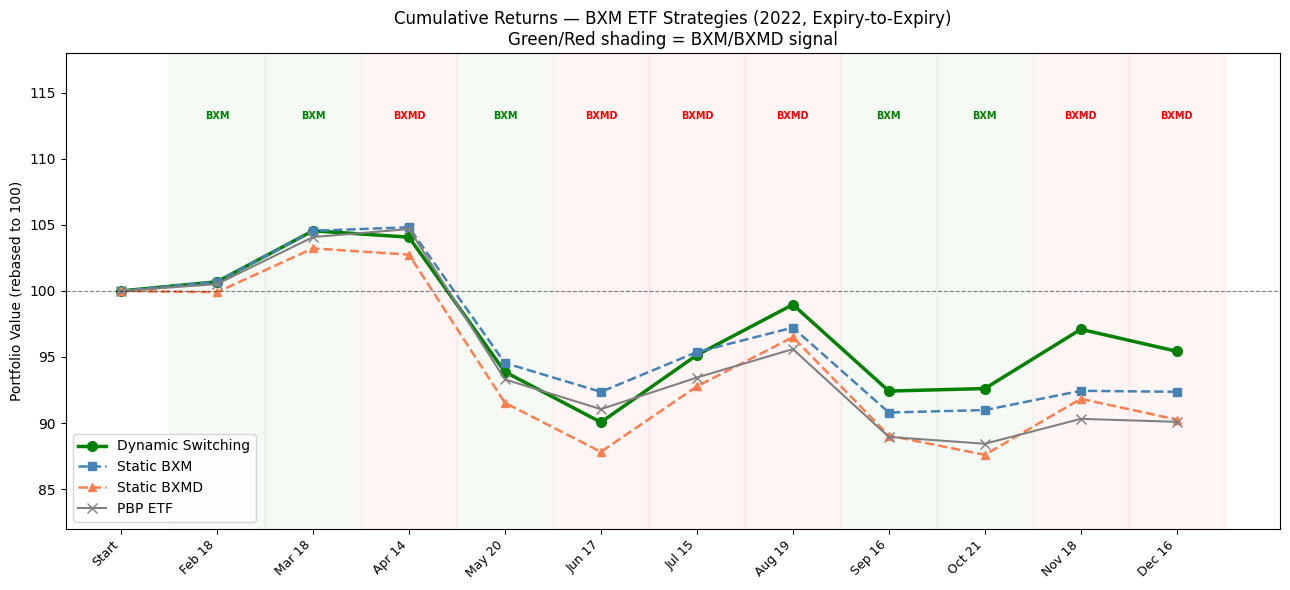

Saved.


In [13]:
# -- Robustness Check 5: Cumulative Return Chart (rebased to 100) --
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

signals = ['BXM', 'BXM', 'BXMD', 'BXM', 'BXMD',
           'BXMD', 'BXMD', 'BXM', 'BXM', 'BXMD', 'BXMD']

r_bxm_actual  = [0.00693, 0.03832, 0.00254, -0.09799,
                 -0.02312, 0.03263, 0.01941, -0.06613,
                  0.00206, 0.01601, -0.00078]

r_bxmd_actual = [-0.00096, 0.03320, -0.00460, -0.10912,
                 -0.04061, 0.05646, 0.04015, -0.07718,
                 -0.01639, 0.04843, -0.01714]

r_dynamic_actual = [r_bxm_actual[i] if signals[i] == 'BXM'
                    else r_bxmd_actual[i] for i in range(11)]

r_pbp = [0.00519, 0.03539, 0.00585, -0.10875,
         -0.02413, 0.02630, 0.02304, -0.06953,
         -0.00581, 0.02130, -0.00248]

def cum_returns(returns, base=100):
    vals = [base]
    for r in returns:
        vals.append(vals[-1] * (1 + r))
    return vals

x = range(12)
labels = ['Start'] + [d.strftime('%b %d') for d in pd.to_datetime([
    "2022-02-18", "2022-03-18", "2022-04-14", "2022-05-20",
    "2022-06-17", "2022-07-15", "2022-08-19", "2022-09-16",
    "2022-10-21", "2022-11-18", "2022-12-16"
])]

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(x, cum_returns(r_dynamic_actual), 'o-',
        color='green', linewidth=2.5, markersize=7, label='Dynamic Switching')
ax.plot(x, cum_returns(r_bxm_actual), 's--',
        color='steelblue', linewidth=1.8, markersize=6, label='Static BXM')
ax.plot(x, cum_returns(r_bxmd_actual), '^--',
        color='coral', linewidth=1.8, markersize=6, label='Static BXMD')
ax.plot(x, cum_returns(r_pbp), 'x-',
        color='gray', linewidth=1.5, markersize=7, label='PBP ETF')

ax.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for i, sig in enumerate(signals):
    ax.axvspan(i+0.5, i+1.5, alpha=0.04,
               color='green' if sig == 'BXM' else 'red')
    ax.text(i+1, 113, sig, ha='center', fontsize=7,
            color='green' if sig == 'BXM' else 'red', fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Portfolio Value (rebased to 100)')
ax.set_title('Cumulative Returns — BXM ETF Strategies (2022, Expiry-to-Expiry)\n'
             'Green/Red shading = BXM/BXMD signal', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(82, 118)

plt.tight_layout()
plt.savefig("../data/processed/cumulative_returns_rebased.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

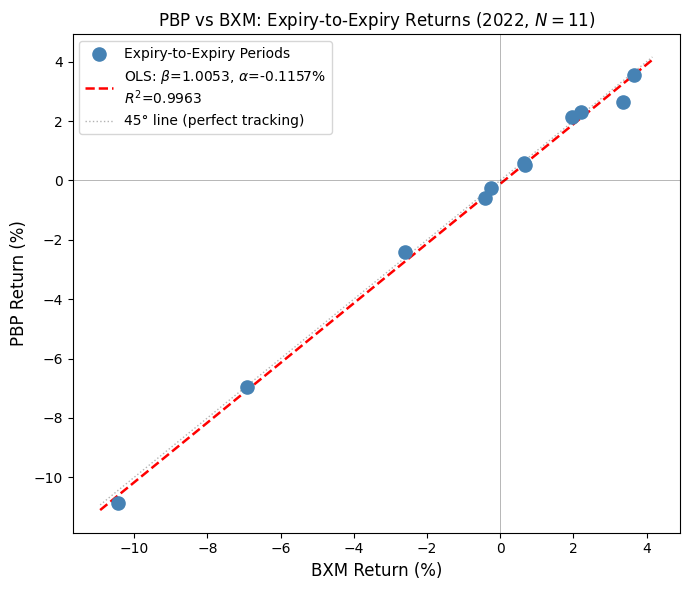

Saved.


In [14]:
# -- Figure 1: Stage 1 Scatter Plot (for paper) --
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Stage 1 expiry-to-expiry data
r_pbp = [0.00519, 0.03539, 0.00585, -0.10875,
         -0.02413, 0.02630, 0.02304, -0.06953,
         -0.00581, 0.02130, -0.00248]

r_bxm = [0.00688, 0.03660, 0.00647, -0.10432,
         -0.02591, 0.03367, 0.02204, -0.06910,
         -0.00407, 0.01975, -0.00249]

slope, intercept, r_value, p_value, std_err = stats.linregress(r_bxm, r_pbp)
r_squared = r_value ** 2

x_line = np.linspace(min(r_bxm) - 0.005, max(r_bxm) + 0.005, 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter([r*100 for r in r_bxm], [r*100 for r in r_pbp],
           color='steelblue', s=90, zorder=3, label='Expiry-to-Expiry Periods')
ax.plot(x_line*100, y_line*100,
        color='red', linewidth=1.8, linestyle='--',
        label=f'OLS: $\\beta$={slope:.4f}, $\\alpha$={intercept*100:.4f}%\n$R^2$={r_squared:.4f}')
ax.plot(x_line*100, x_line*100,
        color='gray', linewidth=1, linestyle=':',
        alpha=0.6, label='45° line (perfect tracking)')

ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
ax.axvline(0, color='black', linewidth=0.5, alpha=0.4)

ax.set_xlabel('BXM Return (%)', fontsize=12)
ax.set_ylabel('PBP Return (%)', fontsize=12)
ax.set_title('PBP vs BXM: Expiry-to-Expiry Returns (2022, $N=11$)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../data/processed/fig1_stage1_scatter.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved.")

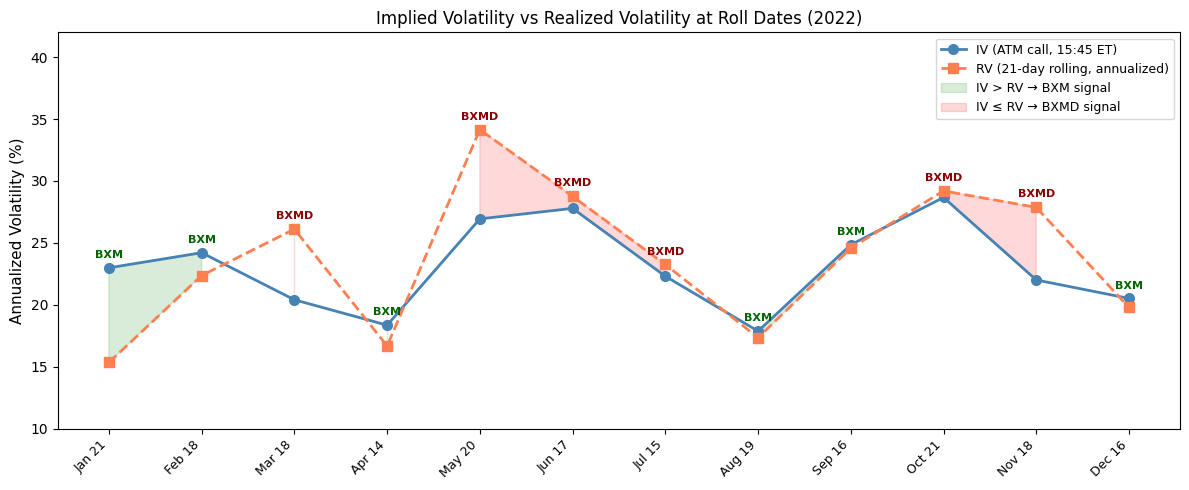

Saved.


In [15]:
# -- Figure 2: IV vs RV Time Series (for paper) --

roll_dates_labels = ['Jan 21', 'Feb 18', 'Mar 18', 'Apr 14',
                     'May 20', 'Jun 17', 'Jul 15', 'Aug 19',
                     'Sep 16', 'Oct 21', 'Nov 18', 'Dec 16']

iv_values = [0.2299, 0.2421, 0.2041, 0.1836,
             0.2694, 0.2779, 0.2231, 0.1788,
             0.2485, 0.2867, 0.2201, 0.2052]

rv_values = [0.1535, 0.2237, 0.2611, 0.1668,
             0.3415, 0.2876, 0.2326, 0.1735,
             0.2458, 0.2920, 0.2787, 0.1979]

spreads   = [iv - rv for iv, rv in zip(iv_values, rv_values)]
signals   = ['BXM' if s > 0 else 'BXMD' for s in spreads]

x = range(len(roll_dates_labels))

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, [v*100 for v in iv_values], 'o-',
        color='steelblue', linewidth=2, markersize=7, label='IV (ATM call, 15:45 ET)')
ax.plot(x, [v*100 for v in rv_values], 's--',
        color='coral', linewidth=2, markersize=7, label='RV (21-day rolling, annualized)')

ax.fill_between(x,
                [v*100 for v in iv_values],
                [v*100 for v in rv_values],
                where=[iv > rv for iv, rv in zip(iv_values, rv_values)],
                alpha=0.15, color='green', label='IV > RV → BXM signal')
ax.fill_between(x,
                [v*100 for v in iv_values],
                [v*100 for v in rv_values],
                where=[iv <= rv for iv, rv in zip(iv_values, rv_values)],
                alpha=0.15, color='red', label='IV ≤ RV → BXMD signal')

# Signal labels
for i, (sig, sp) in enumerate(zip(signals, spreads)):
    color = 'darkgreen' if sig == 'BXM' else 'darkred'
    ypos = max(iv_values[i], rv_values[i])*100 + 0.8
    ax.text(i, ypos, sig, ha='center', fontsize=8,
            color=color, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(roll_dates_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Annualized Volatility (%)', fontsize=11)
ax.set_title('Implied Volatility vs Realized Volatility at Roll Dates (2022)', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(10, 42)

plt.tight_layout()
plt.savefig("../data/processed/fig2_iv_rv_spread.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved.")